# Demand user — Category × Device (README mapping)

Phân khúc **category** theo bảng mã trong **README** (không dùng nhãn cũ trong `eda_demand.ipynb`).

| Mã | Mô tả (README) |
|----|----------------|
| 1010 | Căn Hộ / Chung cư |
| 1020 | Nhà ở |
| 1030 | Văn Phòng, Mặt Bằng |
| 1040 | Đất |
| 1050 | Phòng trọ |

**Demand:** distinct `user_id` có ≥1 sự kiện tích cực (`event_type` theo README).

Chart: stacked **100%** theo category — mỗi hàng = tỉ lệ % **device** trong phân khúc đó.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_ROOT = Path.cwd().resolve()
OUT_DIR = DATA_ROOT / "outputs" / "eda_demand_category_device"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2

EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
POSITIVE_TYPES = (
    "view_phone",
    "contact_chat",
    "other_interaction",
    "contact_zalo",
    "contact_sms",
)
pos_list = ", ".join(repr(x) for x in POSITIVE_TYPES)
CAT_IN = "1010, 1020, 1030, 1040, 1050"

# README.md — Mã danh mục category
CAT_META = pd.DataFrame(
    [
        (1010, "1010 — Căn Hộ / Chung cư"),
        (1020, "1020 — Nhà ở"),
        (1030, "1030 — Văn Phòng, Mặt Bằng"),
        (1040, "1040 — Đất"),
        (1050, "1050 — Phòng trọ"),
    ],
    columns=["category", "category_name"],
)
CAT_ORDER = CAT_META["category"].tolist()
PALETTE = {1010: "#238b45", 1020: "#2171b5", 1030: "#6a51a3", 1040: "#cb181d", 1050: "#d94801"}
# Palette device — khớp legend `eda_demand` (tab20 / matplotlib default)
DEVICE_COLORS = {
    "Android": "#1f77b4",  # xanh dương
    "Desktop": "#d62728",  # đỏ gạch
    "MSite": "#ff9896",    # hồng nhạt
    "iOS": "#aec7e8",      # xanh nhạt
}
DEVICE_EDGE = {
    "Android": "#1565a8",
    "Desktop": "#b01e22",
    "MSite": "#e07a7a",
    "iOS": "#8eb8d8",
}
# Thứ tự category trên chart: 1010 (trên) → 1050 (dưới)
CAT_ORDER_CHART = CAT_ORDER  # ascending 1010…1050


def bar_label_color(hex_color: str) -> str:
    """Chữ trắng trên nền đậm, chữ đậm trên nền sáng."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if lum < 150 else "#2d2d2d"


sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110


def pct_share(series: pd.Series) -> pd.Series:
    total = float(series.sum())
    return series / total * 100.0 if total else series.astype(float)


def pct_row(df: pd.DataFrame) -> pd.DataFrame:
    row_sum = df.sum(axis=1).replace(0, np.nan)
    return df.div(row_sum, axis=0) * 100.0


def order_categories(df: pd.DataFrame, col: str = "category") -> pd.DataFrame:
    out = df.copy()
    out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out[out[col].isin(CAT_ORDER)]
    out[col] = pd.Categorical(out[col].astype(int), categories=CAT_ORDER, ordered=True)
    return out.sort_values(col)


def show_and_save(name: str, **kwargs):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", **kwargs)
    plt.show()
    print("Saved", path)


con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")
print("DATA_ROOT =", DATA_ROOT)
print("DuckDB", duckdb.__version__)

DATA_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data
DuckDB 1.5.2


## Bảng % device trong từng category + chart stacked 100%

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

device,Android,iOS,Desktop,MSite
category_name,,,,
1010 — Căn Hộ / Chung cư,131198,134551,240971,354461
1020 — Nhà ở,221416,189583,288603,770203
"1030 — Văn Phòng, Mặt Bằng",53412,57221,70663,81910
1040 — Đất,152169,62612,161759,206986
1050 — Phòng trọ,113287,218348,204851,368303


device,Android,iOS,Desktop,MSite
category_name,,,,
1010 — Căn Hộ / Chung cư,15.2,15.6,28.0,41.2
1020 — Nhà ở,15.1,12.9,19.6,52.4
"1030 — Văn Phòng, Mặt Bằng",20.3,21.7,26.8,31.1
1040 — Đất,26.1,10.7,27.7,35.5
1050 — Phòng trọ,12.5,24.1,22.6,40.7


/var/folders/gl/t2pfk0nn6r11bnblrgzwmq8m0000gn/T/ipykernel_3894/392464348.py:97: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.savefig(path, bbox_inches="tight", **kwargs)
/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


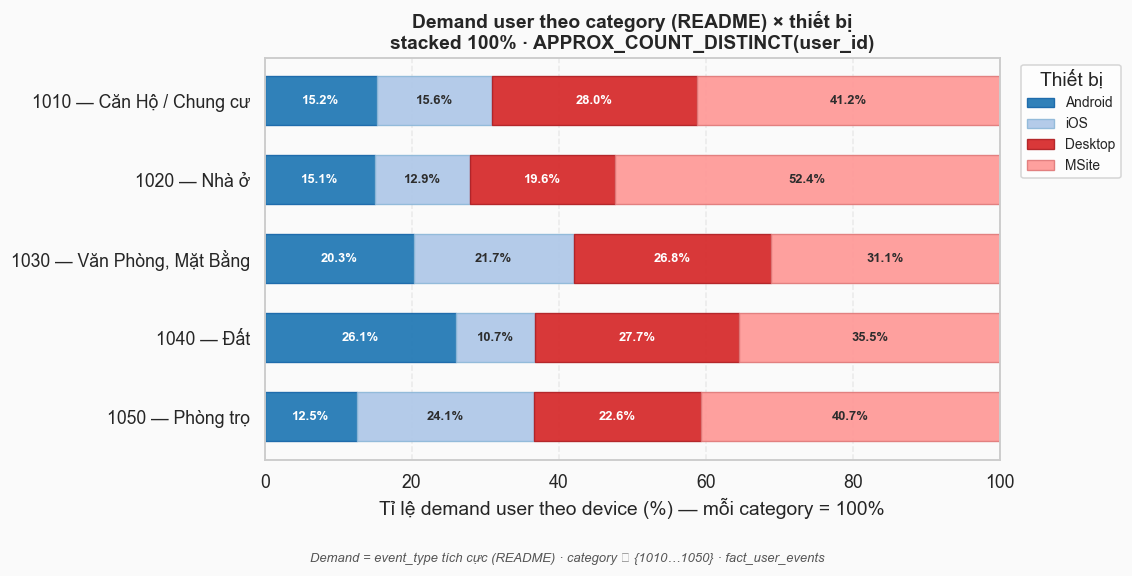

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_demand_category_device/demand_category_device_stacked_readme.png


In [2]:
by_cat_dev = con.execute(
    f"""
    SELECT category, device, APPROX_COUNT_DISTINCT(user_id) AS demand_users
    FROM read_parquet(?)
    WHERE event_type IN ({pos_list})
      AND user_id IS NOT NULL
      AND category IN ({CAT_IN})
      AND device IS NOT NULL
    GROUP BY 1, 2
    ORDER BY 1, 2
    """,
    [EVENTS_GLOB],
).df()

by_cat_dev = order_categories(by_cat_dev.merge(CAT_META, on="category", how="left"))
by_cat_dev.to_csv(OUT_DIR / "01_demand_users_category_device.csv", index=False)

pivot = by_cat_dev.pivot_table(
    index="category_name", columns="device", values="demand_users", fill_value=0
)
# Hàng pivot: 1010 → 1050 (sẽ đảo trục Y để 1010 nằm trên cùng chart)
_order = CAT_META.set_index("category").reindex(CAT_ORDER_CHART)["category_name"].tolist()
pivot = pivot.reindex(_order)

# Thứ tự segment trái→phải (giống eda_demand): Android → iOS → Desktop → MSite
dev_order = [c for c in ["Android", "iOS", "Desktop", "MSite"] if c in pivot.columns]
dev_order += [c for c in pivot.columns if c not in dev_order]
pivot = pivot[dev_order]

pivot_pct = pct_row(pivot)
display(pivot.round(0).astype("Int64"))
display(pivot_pct.round(1))
pivot_pct.round(2).to_csv(OUT_DIR / "02_device_pct_within_category.csv")

fig, ax = plt.subplots(figsize=(10.5, 5))
fig.patch.set_facecolor("#fafafa")
ax.set_facecolor("#fafafa")
left = np.zeros(len(pivot_pct))
y = np.arange(len(pivot_pct))
bar_h = 0.62

for col in pivot_pct.columns:
    color = DEVICE_COLORS.get(col, "#9ecae1")
    edge = DEVICE_EDGE.get(col, "#7a9eb8")
    vals = pivot_pct[col].to_numpy()
    bars = ax.barh(
        y,
        vals,
        left=left,
        height=bar_h,
        label=col,
        color=color,
        edgecolor=edge,
        linewidth=0.9,
        alpha=0.92,
    )
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v >= 3.5:
            ax.text(
                left[i] + v / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="600",
                color=bar_label_color(color),
            )
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(pivot_pct.index.tolist())
ax.invert_yaxis()  # 1010 trên cùng, 1050 dưới cùng (đọc từ 10 → 50)
ax.set_xlim(0, 100)
ax.set_xlabel("Tỉ lệ demand user theo device (%) — mỗi category = 100%")
ax.set_title(
    "Demand user theo category (README) × thiết bị\nstacked 100% · APPROX_COUNT_DISTINCT(user_id)",
    fontweight="bold",
)
ax.grid(axis="x", alpha=0.35, linestyle="--")
ax.grid(axis="y", visible=False)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    labels,
    title="Thiết bị",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
)
fig.text(
    0.5,
    -0.04,
    "Demand = event_type tích cực (README) · category ∈ {1010…1050} · fact_user_events",
    ha="center",
    fontsize=8.5,
    style="italic",
    color="#555",
)
show_and_save("demand_category_device_stacked_readme.png", dpi=150)